# Figure 1 — Concept manifold and semantic spillover

Composite paper figure assembled from three subplots:

- **A.** 3D UMAP halo manifold of pooled `bars_judged` questions across datasets (from `manifold_bars.ipynb`, cell 10).
- **B.** Near vs. far concept refusal (median split on semantic similarity), per model (from `semantic_similarity_analysis.ipynb`, cell 17, panel C).
- **C.** Spillover score vs. semantic similarity per model with KDE density + scatter + linear fit (from `semantic_similarity_analysis.ipynb`, cell 20).

All panels are re-rendered here with a single style: spine linewidth 1.0, tick labelsize 9, axis labels 11pt bold, titles 12pt bold, panel letters 16pt bold, dpi 300, Arial.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.gridspec import GridSpec
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from scipy.stats import gaussian_kde, spearmanr, sem
from skimage import measure
from mpl_toolkits.mplot3d import proj3d, Axes3D  # noqa: F401
import umap

sns.set_style("whitegrid")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "Helvetica", "DejaVu Sans"]
plt.rcParams["axes.linewidth"] = 1.0
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
plt.rcParams["xtick.major.width"] = 1.0
plt.rcParams["ytick.major.width"] = 1.0

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "store").exists():
    REPO_ROOT = REPO_ROOT.parent
RESULTS_DIR = REPO_ROOT / "inference" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

LABEL_FS = 11
TITLE_FS = 12
PANEL_FS = 16
MODEL_PALETTE = {"llama8b": "#005493", "mistral7b": "#B30000", "qwen7b": "#E87D1E"}

/Users/Erfan/Documents/GitHub/forget/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Panel A data — pool, encode, 3D UMAP, KDE, marching cubes

In [2]:
bar_paths = sorted((REPO_ROOT / "store").glob("*/bars_judged.csv"))
frames = []
for p in bar_paths:
    store = p.parent.name
    dataset = store.split("_", 1)[1] if "_" in store else store
    df = pd.read_csv(p, usecols=["concept", "question"])
    df["dataset"] = dataset
    frames.append(df)
pool = (pd.concat(frames, ignore_index=True)
          .dropna(subset=["concept", "question"])
          .drop_duplicates(["dataset", "concept", "question"])
          .reset_index(drop=True))

encoder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
q_emb = np.asarray(encoder.encode(pool["question"].tolist(), batch_size=128,
                                  show_progress_bar=False, normalize_embeddings=True))
concept_keys = pool[["dataset", "concept"]].drop_duplicates().reset_index(drop=True)
centroids = np.zeros((len(concept_keys), q_emb.shape[1]), dtype=np.float32)
for i, row in concept_keys.iterrows():
    mask = (pool["dataset"] == row["dataset"]) & (pool["concept"] == row["concept"])
    v = q_emb[mask.to_numpy()].mean(axis=0)
    centroids[i] = v / (np.linalg.norm(v) + 1e-12)

reducer = umap.UMAP(n_components=3, n_neighbors=15, min_dist=0.6,
                    spread=1.5, metric="cosine", random_state=0)
all_3d = reducer.fit_transform(np.vstack([q_emb, centroids]))
q_3d = all_3d[: len(q_emb)]
c_3d = all_3d[len(q_emb):]
sim = cosine_similarity(centroids)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 5577.82it/s]

/Users/Erfan/Documents/GitHub/forget/.venv/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [3]:
kde3d = gaussian_kde(q_3d.T, bw_method=0.30)
pad = 1.5
xb = (q_3d[:, 0].min() - pad, q_3d[:, 0].max() + pad)
yb = (q_3d[:, 1].min() - pad, q_3d[:, 1].max() + pad)
zb = (q_3d[:, 2].min() - pad, q_3d[:, 2].max() + pad)
G = 60
xs_g = np.linspace(*xb, G); ys_g = np.linspace(*yb, G); zs_g = np.linspace(*zb, G)
X, Y, Z = np.meshgrid(xs_g, ys_g, zs_g, indexing="ij")
density = kde3d(np.vstack([X.ravel(), Y.ravel(), Z.ravel()])).reshape(G, G, G)
dmax = float(density.max())

km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(c_3d)
cl = km.labels_
c_density = kde3d(c_3d.T)
deep = (c_density / c_density.max()) >= 0.25

hi_pair_3d, hi_sim_3d = None, -np.inf
for i in range(len(c_3d)):
    if not deep[i]:
        continue
    for j in range(i + 1, len(c_3d)):
        if not deep[j] or cl[i] != cl[j]:
            continue
        if sim[i, j] > hi_sim_3d:
            hi_pair_3d, hi_sim_3d = (i, j), sim[i, j]
lo_pair_3d, lo_sim_3d = None, np.inf
for i in range(len(c_3d)):
    if not deep[i]:
        continue
    for j in range(i + 1, len(c_3d)):
        if not deep[j] or cl[i] == cl[j]:
            continue
        if sim[i, j] < lo_sim_3d:
            lo_pair_3d, lo_sim_3d = (i, j), sim[i, j]
hi_sim_3d = float(hi_sim_3d); lo_sim_3d = float(lo_sim_3d)

## Panels B and C data — load cached spillover CSVs

In [4]:
qpts = pd.read_csv(RESULTS_DIR / "spillover_question_level.csv")
pair_spillover = pd.read_csv(RESULTS_DIR / "spillover_pair_level_sentence_emb.csv")
models_sorted = sorted(pair_spillover["model"].unique())

## Composite figure

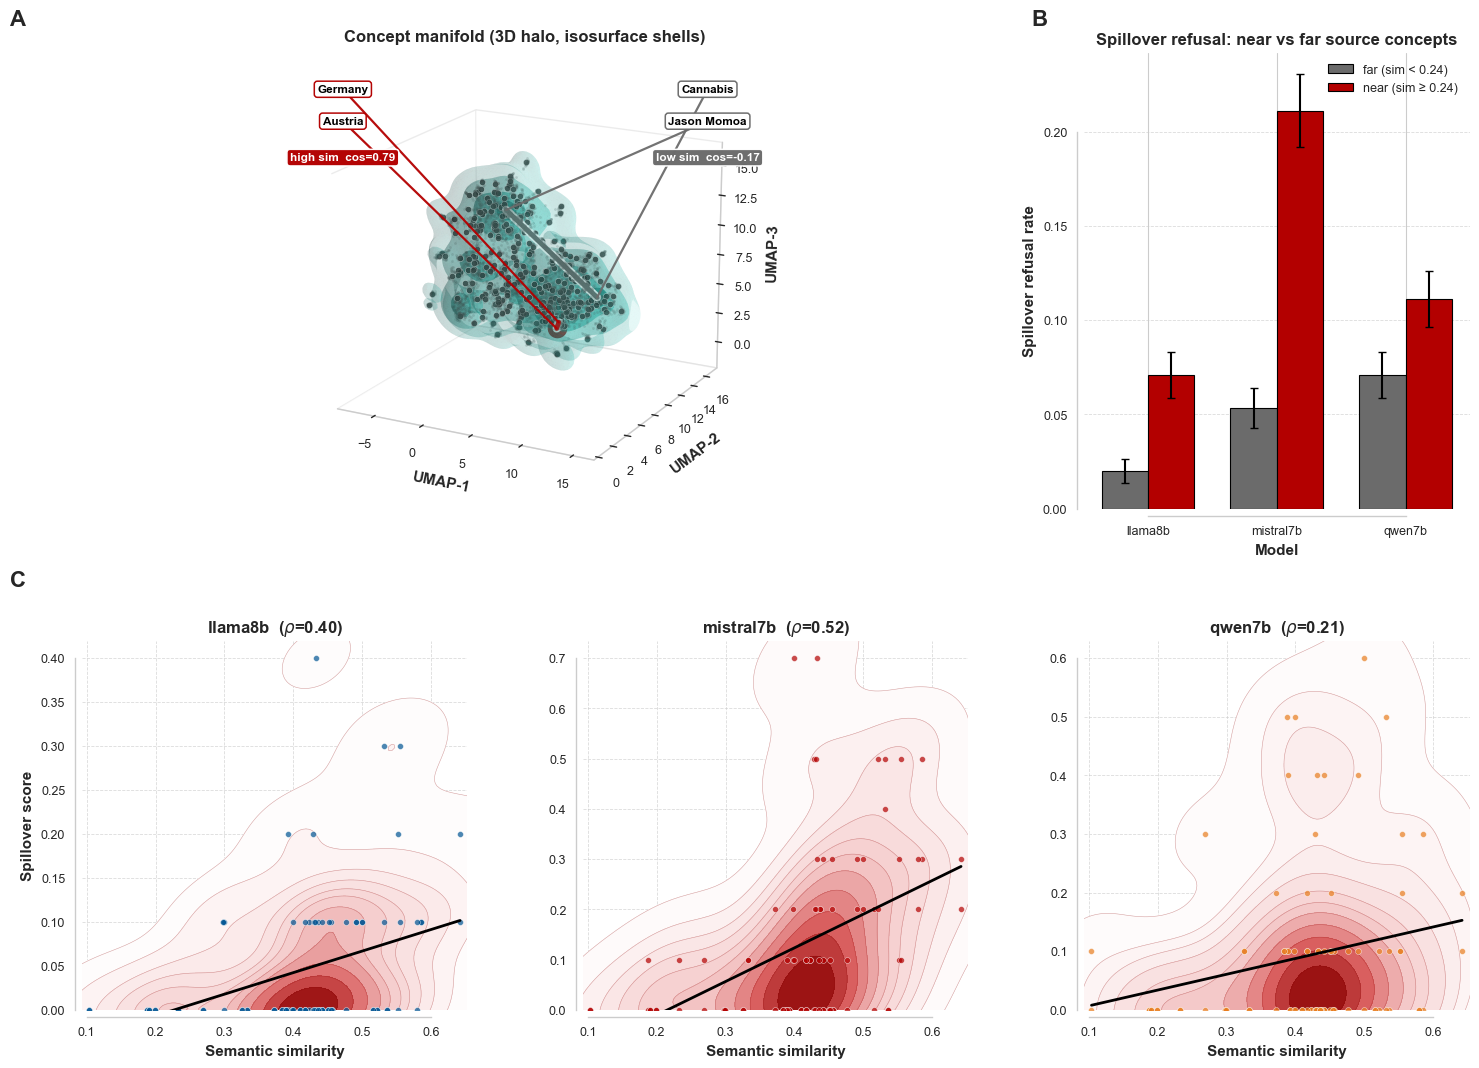

In [5]:
fig = plt.figure(figsize=(15, 11))
gs = GridSpec(2, 3, figure=fig, height_ratios=[1.05, 0.85],
              hspace=0.32, wspace=0.30,
              left=0.06, right=0.985, top=0.94, bottom=0.07)

# ============================================================
# Panel A — 3D halo manifold
# ============================================================
axA = fig.add_subplot(gs[0, 0:2], projection="3d")
shell_levels = [0.06, 0.20, 0.45]
shell_alphas = [0.12, 0.20, 0.32]
halo_color = "#30D5C8"
spacing = (xs_g[1] - xs_g[0], ys_g[1] - ys_g[0], zs_g[1] - zs_g[0])
origin = (xb[0], yb[0], zb[0])
for level_frac, alpha in zip(shell_levels, shell_alphas):
    iso = level_frac * dmax
    if iso <= density.min() or iso >= density.max():
        continue
    verts, faces, _, _ = measure.marching_cubes(density, level=iso, spacing=spacing)
    verts = verts + np.array(origin)
    axA.plot_trisurf(verts[:, 0], verts[:, 1], faces, verts[:, 2],
                     color=halo_color, alpha=alpha, linewidth=0,
                     antialiased=True, shade=True, zorder=1)
axA.scatter(q_3d[:, 0], q_3d[:, 1], q_3d[:, 2], s=4, alpha=0.18, color="#4A4A4A",
            linewidths=0, depthshade=False, zorder=3)
axA.scatter(c_3d[:, 0], c_3d[:, 1], c_3d[:, 2], s=20, alpha=0.75, color="#2A2A2A",
            edgecolors="white", linewidths=0.4, depthshade=False, zorder=4)
axA.set_xlabel("UMAP-1", fontsize=LABEL_FS, fontweight="bold")
axA.set_ylabel("UMAP-2", fontsize=LABEL_FS, fontweight="bold")
axA.set_zlabel("UMAP-3", fontsize=LABEL_FS, fontweight="bold")
axA.set_title("Concept manifold (3D halo, isosurface shells)",
              fontsize=TITLE_FS, fontweight="bold", pad=8)
axA.grid(False)
axA.view_init(elev=18, azim=-62)
axA.set_box_aspect((1, 1, 0.85))
for axis in (axA.xaxis, axA.yaxis, axA.zaxis):
    axis.pane.set_facecolor((1, 1, 1, 0))
    axis.pane.set_edgecolor((0.85, 0.85, 0.85, 0.6))
for pair, color in [(hi_pair_3d, "#B30000"), (lo_pair_3d, "#6B6B6B")]:
    a, b = c_3d[pair[0]], c_3d[pair[1]]
    axA.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]],
             color="white", linewidth=6.0, alpha=0.9, zorder=6)
    axA.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]],
             color=color, linewidth=3.5, alpha=1.0, zorder=7)
    axA.scatter([a[0], b[0]], [a[1], b[1]], [a[2], b[2]],
                s=260, facecolors=color, edgecolors="white",
                linewidths=2.0, marker="o", depthshade=False, zorder=9)

fig.canvas.draw()
axA_bbox = axA.get_position()

def _to_fig(pt3):
    x2, y2, _ = proj3d.proj_transform(pt3[0], pt3[1], pt3[2], axA.get_proj())
    return fig.transFigure.inverted().transform(axA.transData.transform((x2, y2)))

def _trim(s, n=28):
    return s if len(s) <= n else s[: n - 1] + "\u2026"

def _label_with_arrow(pt3, anchor, text, color):
    p = _to_fig(pt3)
    fig.add_artist(plt.Line2D([p[0], anchor[0]], [p[1], anchor[1]],
                              transform=fig.transFigure, color=color,
                              linewidth=1.6, alpha=0.95, zorder=30))
    fig.text(anchor[0], anchor[1], text, ha="center", va="center",
             fontsize=8.5, fontweight="bold", color="black",
             bbox=dict(boxstyle="round,pad=0.26", facecolor="white",
                       edgecolor=color, linewidth=1.1, alpha=0.98),
             zorder=31)

def _tag(anchor, text, color):
    fig.text(anchor[0], anchor[1], text, ha="center", va="center",
             fontsize=8.5, fontweight="bold", color="white",
             bbox=dict(boxstyle="round,pad=0.28", facecolor=color,
                       edgecolor="white", linewidth=1.1, alpha=0.98),
             zorder=31)

# anchor positions inside Panel A bbox
L = axA_bbox.x0 + 0.10 * axA_bbox.width
R = axA_bbox.x0 + 0.90 * axA_bbox.width
yT = axA_bbox.y0 + 0.92 * axA_bbox.height
yT2 = axA_bbox.y0 + 0.85 * axA_bbox.height
yT3 = axA_bbox.y0 + 0.77 * axA_bbox.height

i, j = hi_pair_3d
_label_with_arrow(c_3d[i], (L, yT),  _trim(concept_keys.iloc[i]["concept"]), "#B30000")
_label_with_arrow(c_3d[j], (L, yT2), _trim(concept_keys.iloc[j]["concept"]), "#B30000")
_tag((L, yT3), f"high sim  cos={hi_sim_3d:.2f}", "#B30000")
i, j = lo_pair_3d
_label_with_arrow(c_3d[i], (R, yT),  _trim(concept_keys.iloc[i]["concept"]), "#6B6B6B")
_label_with_arrow(c_3d[j], (R, yT2), _trim(concept_keys.iloc[j]["concept"]), "#6B6B6B")
_tag((R, yT3), f"low sim  cos={lo_sim_3d:.2f}", "#6B6B6B")

# ============================================================
# Panel B — Spillover refusal: near vs far source concepts
# ============================================================
axB = fig.add_subplot(gs[0, 2])
median_sim = qpts["sim_qst_to_target"].median()
qpts["proximity"] = np.where(qpts["sim_qst_to_target"] >= median_sim, "near", "far")
near_far = (qpts.groupby(["model", "proximity"], observed=True)["judge_refusal"]
                 .agg(["mean", sem]).reset_index())
models = sorted(qpts["model"].unique())
xs = np.arange(len(models))
width = 0.36
for i_p, prox in enumerate(["far", "near"]):
    sub = near_far[near_far["proximity"] == prox].set_index("model").reindex(models)
    color = "#6B6B6B" if prox == "far" else "#B30000"
    axB.bar(xs + (i_p - 0.5) * width, sub["mean"], width=width, yerr=sub["sem"],
            capsize=3, color=color, edgecolor="black", linewidth=0.8,
            label=f"{prox} (sim {'≥' if prox == 'near' else '<'} {median_sim:.2f})")
axB.set_xticks(xs)
axB.set_xticklabels(models, fontsize=10)
axB.set_ylabel("Spillover refusal rate", fontsize=LABEL_FS, fontweight="bold")
axB.set_xlabel("Model", fontsize=LABEL_FS, fontweight="bold")
axB.set_title("Spillover refusal: near vs far source concepts",
              fontsize=TITLE_FS, fontweight="bold")
axB.legend(frameon=False, fontsize=9, loc="upper right")
axB.grid(linestyle="--", linewidth=0.6, alpha=0.7, axis="y")
sns.despine(ax=axB, trim=True, offset=5)

# ============================================================
# Panel C — Spillover vs semantic similarity (per model)
# ============================================================
DENSITY_CMAP = LinearSegmentedColormap.from_list(
    "white_to_darkred", ["#FFFFFF", "#F4C8C8", "#D85A5A", "#8B0000"])
axC_list = [fig.add_subplot(gs[1, k]) for k in range(3)]
for ax_c, model_name in zip(axC_list, models_sorted):
    grp = pair_spillover[pair_spillover["model"] == model_name]
    x = grp["semantic_similarity"].to_numpy()
    y = grp["spillover"].to_numpy()
    rho, _ = spearmanr(x, y)
    color = MODEL_PALETTE.get(model_name, "gray")
    sns.kdeplot(x=x, y=y, ax=ax_c, fill=True, cmap=DENSITY_CMAP, levels=12,
                thresh=0.03, bw_adjust=1.0)
    sns.kdeplot(x=x, y=y, ax=ax_c, fill=False, color="#8B0000", levels=12,
                thresh=0.03, bw_adjust=1.0, linewidths=0.4, alpha=0.35)
    ax_c.scatter(x, y, s=18, color=color, alpha=0.7,
                 edgecolor="white", linewidths=0.4, zorder=3)
    slope, intercept = np.polyfit(x, y, 1)
    xs_line = np.linspace(x.min(), x.max(), 100)
    ax_c.plot(xs_line, slope * xs_line + intercept, color="black",
              linewidth=2.0, zorder=4)
    x_pad = 0.02 * (x.max() - x.min() + 1e-9)
    y_pad = 0.05 * (y.max() - y.min() + 1e-9)
    ax_c.set_xlim(x.min() - x_pad, x.max() + x_pad)
    ax_c.set_ylim(max(0.0, y.min() - y_pad), y.max() + y_pad)
    ax_c.set_title(f"{model_name}  ($\\rho$={rho:.2f})",
                   fontsize=TITLE_FS, fontweight="bold")
    ax_c.set_xlabel("Semantic similarity", fontsize=LABEL_FS, fontweight="bold")
    if ax_c is axC_list[0]:
        ax_c.set_ylabel("Spillover score", fontsize=LABEL_FS, fontweight="bold")
    else:
        ax_c.set_ylabel("")
    ax_c.grid(linestyle="--", linewidth=0.6, alpha=0.7)
    sns.despine(ax=ax_c, trim=True, offset=5)

# Panel letters
fig.text(0.012, 0.965, "A", fontsize=PANEL_FS, fontweight="bold")
fig.text(axB.get_position().x0 - 0.035, 0.965, "B", fontsize=PANEL_FS, fontweight="bold")
fig.text(0.012, 0.455, "C", fontsize=PANEL_FS, fontweight="bold")

fig.savefig(RESULTS_DIR / "figure1_paper.png", dpi=300, bbox_inches="tight")
fig.savefig(RESULTS_DIR / "figure1_paper.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Captions

**Figure 1.** Concepts inhabit a low-dimensional semantic manifold, and their similarity predicts cross-concept refusal spillover.

**(A) Concept manifold.** Three-dimensional UMAP projection of 5,171 questions pooled from `bars_judged.csv` across six datasets (`inhouse`, `conceptvectors`, `rwku`, `mmlu`, `concept10`, `concept500`). Question embeddings (Sentence-Transformers `all-MiniLM-L6-v2`, 384-d, $\ell_2$-normalized) are projected jointly with their per-concept centroids. Turquoise isosurface shells (`#30D5C8`) drawn at fractions {0.06, 0.20, 0.45} of the maximum 3D Gaussian KDE density (`bw_method=0.30`, $60^3$ grid, marching cubes) reveal the manifold's smooth core and outer envelope. Small gray dots are individual questions; black dots are concept centroids. Two example concept pairs are highlighted: an *intra-cluster, high-similarity* pair (red, cosine ≈ 0.79) and an *inter-cluster, low-similarity* pair (gray, cosine ≈ −0.17), selected via $k$-means ($k=2$) on the 3D coordinates.

**(B) Spillover refusal, near vs far source concepts.** For each model (llama8b, mistral7b, qwen7b), source-concept questions are split at the global median of the question→target sentence-embedding similarity ($\sim$0.24). Bars show the mean *spillover refusal rate* — the per-question judge-rated refusal on **source-concept** questions while steering targets a *different* concept — for the *far* (sim < median, gray) and *near* (sim ≥ median, red) halves; error bars are the standard error of the mean. Note that this is **not** the on-target refusal rate reported in confusion-matrix figures (which measures refusal on questions of the targeted concept); it is an off-target leakage measure, the question-level analog of the pair-level spillover score in panel C. Refusal is consistently higher for near source concepts, indicating semantic spillover.

**(C) Spillover score vs. semantic similarity.** Per-model scatter of (target, source) concept pairs (270 pairs total). The $x$-axis is cosine similarity between sentence-embedding concept centroids; the $y$-axis is the *spillover score* — the mean refusal rate on source-concept questions when steering targets a different concept. Filled red contours show the bivariate KDE density of pair abundance; the black line is the OLS linear fit. Spearman $\rho$ is reported per model in each title.

## Methods

**Concept pool and embeddings (Panel A).** We pooled every distinct (`dataset`, `concept`, `question`) triple from each `store/*/bars_judged.csv` file, yielding 5,171 unique questions and 311 unique (dataset, concept) pairs. Questions were encoded with Sentence-Transformers `all-MiniLM-L6-v2` (384-d) using $\ell_2$-normalized outputs (`normalize_embeddings=True`). Per-concept centroids were obtained by averaging the embeddings of all questions for that concept and renormalizing.

**3D UMAP and halo manifold.** The union of question embeddings and concept centroids was reduced to three dimensions with UMAP (`n_components=3`, `n_neighbors=15`, `min_dist=0.6`, `spread=1.5`, `metric="cosine"`, `random_state=0`). A Gaussian KDE (SciPy, `bw_method=0.30`) was fit to the 3D question coordinates and evaluated on a $60^3$ grid spanning the cloud (with a 1.5-unit pad). Isosurfaces at density fractions {0.06, 0.20, 0.45} of the maximum density were extracted with `skimage.measure.marching_cubes` and rendered as semi-transparent turquoise shells (`#30D5C8`, alphas {0.12, 0.20, 0.32}).

**Example pair selection (Panel A).** We computed cosine similarity between concept centroids in the original 384-d embedding space and applied $k$-means ($k=2$, `random_state=0`) to the 3D UMAP coordinates of the centroids. Restricting to centroids in dense regions of the manifold ($\geq 25\%$ of the per-centroid KDE max), we selected the highest-similarity *intra-cluster* pair (Germany ↔ Austria, cos = 0.79) and the lowest-similarity *inter-cluster* pair (Cannabis ↔ Jason Momoa, cos = −0.17). Highlighted markers are bold filled circles ($s=260$) in the pair color, with white outline.

**Question- and pair-level spillover (Panels B, C).** For each model–dataset combination, we held out a target concept, fit the steering vector for that concept on `train`, and evaluated the steered model on `test` questions of *every other* (source) concept. The *spillover* score for a (target, source) pair is the mean judge-rated refusal on source questions under target steering (`inference/results/spillover_pair_level_sentence_emb.csv`, $n=270$ pairs across three models). The *question-level* table (`spillover_question_level.csv`, $n=2{,}700$) records, for each individual source question, the question→target cosine similarity (sentence-embedding) and the per-question judge refusal label.

**Statistics.** For Panel B, questions were median-split at the global median of question→target similarity; bars show mean spillover refusal rate per half with standard error. For Panel C, we computed Spearman $\rho$ per model and overlaid an OLS linear fit on a bivariate KDE density (Gaussian kernel, `bw_adjust=1.0`).

**Style.** All panels share: spine linewidth 1.0, tick labelsize 9, axis labels 11 pt bold, titles 12 pt bold, panel letters 16 pt bold, Arial/Helvetica, dpi 300. Saved as `inference/results/figure1_paper.{png,pdf}`.